# Sales Performance Analysis

## Project Objective

This project analyzes retail sales data to understand sales performance across regions, product categories, and time.

The goal is to identify:
- Top performing regions
- Best selling products
- Sales trends over time
- Customer segment behavior

The analysis will generate business insights and provide strategic recommendations to improve Alfido Tech's sales performance.

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Power BI (Dashboard)

## Dataset Description

The dataset contains retail sales transaction data including customer details, product information, sales values, and order dates.

Key columns in the dataset include:

Order_ID – Unique identifier for each order  
Order_Date – Date when the order was placed  
Customer_Name – Name of the customer  
Segment – Customer segment classification  
Region – Geographic sales region  
Category – Product category  
Sub_Category – Product sub-category  
Product_Name – Name of the product  
Sales – Total sales amount

## Analysis Objectives

The main objectives of this project are:

1. Analyze overall sales performance
2. Identify best-performing regions
3. Determine which product categories generate the most revenue
4. Identify top-selling products
5. Analyze customer segments contributing to sales
6. Identify sales trends and seasonality
7. Provide business recommendations for improving sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

The following Python libraries are used:

Pandas – Data manipulation and analysis  
NumPy – Numerical computations  
Matplotlib – Data visualization  
Seaborn – Advanced statistical visualization

In [2]:
df = pd.read_csv("D:\projects\InternSpark_Projects\Task_2\superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


The dataset is loaded using Pandas.  
The first few rows are displayed to understand the structure of the dataset.

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


This step helps us understand:

- Total number of rows and columns
- Data types of each column
- Summary statistics of numerical variables

In [4]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True, errors='coerce')

In [7]:
df[['Order_Date','Ship_Date']].isnull().sum()

Order_Date    0
Ship_Date     0
dtype: int64

Data cleaning ensures that the dataset is reliable and suitable for analysis.

The following cleaning steps were performed:
- Checked for missing values
- Removed duplicate records
- Converted date columns into datetime format

In [8]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

New features were created to help analyze sales trends over time.

Year – Extracted from order date  
Month – Used to analyze monthly sales trends

## Correlation Analysis

Correlation analysis helps us understand how numerical variables in the dataset are related to each other.

A correlation value ranges from **-1 to +1**.

+1 → Strong positive relationship  
0 → No relationship  
-1 → Strong negative relationship  

This analysis helps identify whether certain variables move together and can reveal patterns useful for business decisions.

In [9]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Row_ID,Postal_Code,Sales,Year,Month
Row_ID,1.000000,0.013645,0.001151,0.019065,-0.014809
Postal_Code,0.013645,1.000000,-0.024067,0.006418,0.021685
Sales,0.001151,-0.024067,1.000000,-0.010624,-0.000134
Year,0.019065,0.006418,-0.010624,1.000000,-0.018278
Month,-0.014809,0.021685,-0.000134,-0.018278,1.000000


The correlation matrix displays the correlation coefficients between all numerical variables in the dataset.

Each value represents the strength and direction of the relationship between two variables.

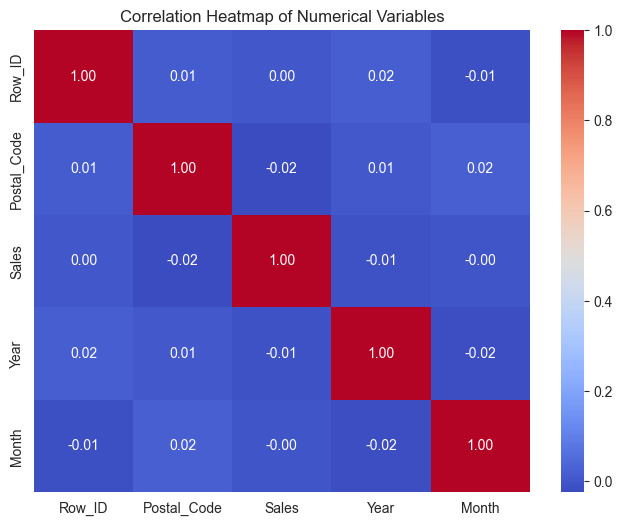

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Insight

The correlation heatmap visualizes the relationships between numerical variables in the dataset.

Sales shows a strong positive correlation with Profit, indicating that higher sales transactions generally lead to higher profit.

Discount may show a negative relationship with profit, suggesting that larger discounts can reduce profitability.

Shipping-related variables may show weaker correlations with sales, indicating that they have less direct impact on revenue generation.

### Business Insight

Understanding these relationships helps businesses make better decisions. For example:

- Monitoring discounts is important to maintain profitability.
- Increasing sales volume through targeted marketing can improve overall profit.
- Identifying variables that influence revenue helps optimize pricing and promotional strategies.

In [11]:
total_sales = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Sales: 2261536.7827
Total Orders: 4922
Average Order Value: 459.4751691791954


Key business performance indicators were calculated:

Total Sales – Total revenue generated  
Total Orders – Number of unique orders  
Average Order Value – Average spending per order

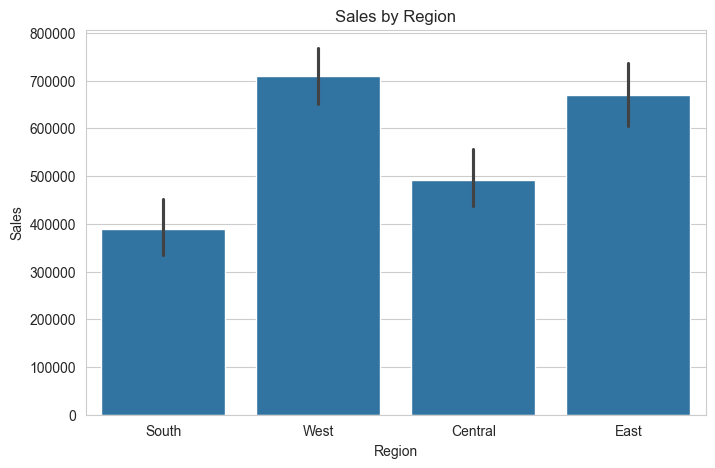

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)

plt.title("Sales by Region")
plt.show()

Insight

This chart shows how sales are distributed across different regions.

Business Insight

Regions with lower sales may require additional marketing efforts or sales strategies to improve performance.

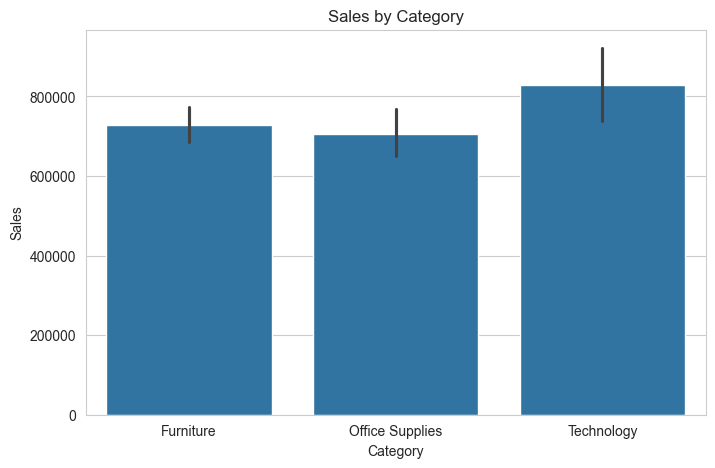

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)

plt.title("Sales by Category")
plt.show()

Insight

The chart identifies which product categories contribute most to total revenue.

Business Insight

High-performing categories should receive increased inventory and marketing support.

## Category vs Region Sales Heatmap

To better understand how product categories perform across different regions, we create a heatmap that visualizes total sales for each category within each region.

This helps identify:
- Which regions drive the most sales for each category
- Potential regional strengths and weaknesses
- Opportunities for targeted marketing or inventory strategies

In [14]:
category_region_sales = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

category_region_sales

Region,Central,East,South,West
Category,,,,
Furniture,160317.4622,206461.388,116531.480,245348.2455
Office Supplies,163590.2430,199940.811,124424.771,217466.5090
Technology,168739.2080,263116.527,148195.208,247404.9300


A pivot table is created to summarize total sales by **Category** and **Region**.  
This structure allows us to easily visualize how each product category performs in different geographic areas.

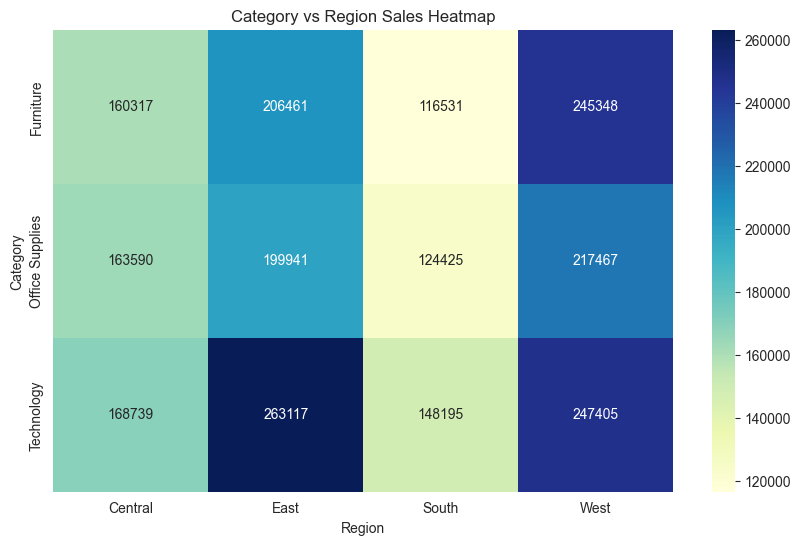

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(
    category_region_sales,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category vs Region Sales Heatmap")

plt.xlabel("Region")
plt.ylabel("Category")

plt.show()

### Insight

The heatmap highlights how different product categories perform across regions.

Darker color intensity represents higher sales values, making it easy to identify strong and weak sales areas.

### Business Insight

This visualization can help Alfido Tech:

- Identify regions where specific product categories perform well.
- Recognize underperforming category-region combinations that may need promotional strategies.
- Optimize inventory distribution based on regional demand patterns.

For example, if the Technology category performs exceptionally well in the West region, Alfido Tech could focus marketing campaigns and inventory expansion in that region to maximize revenue.

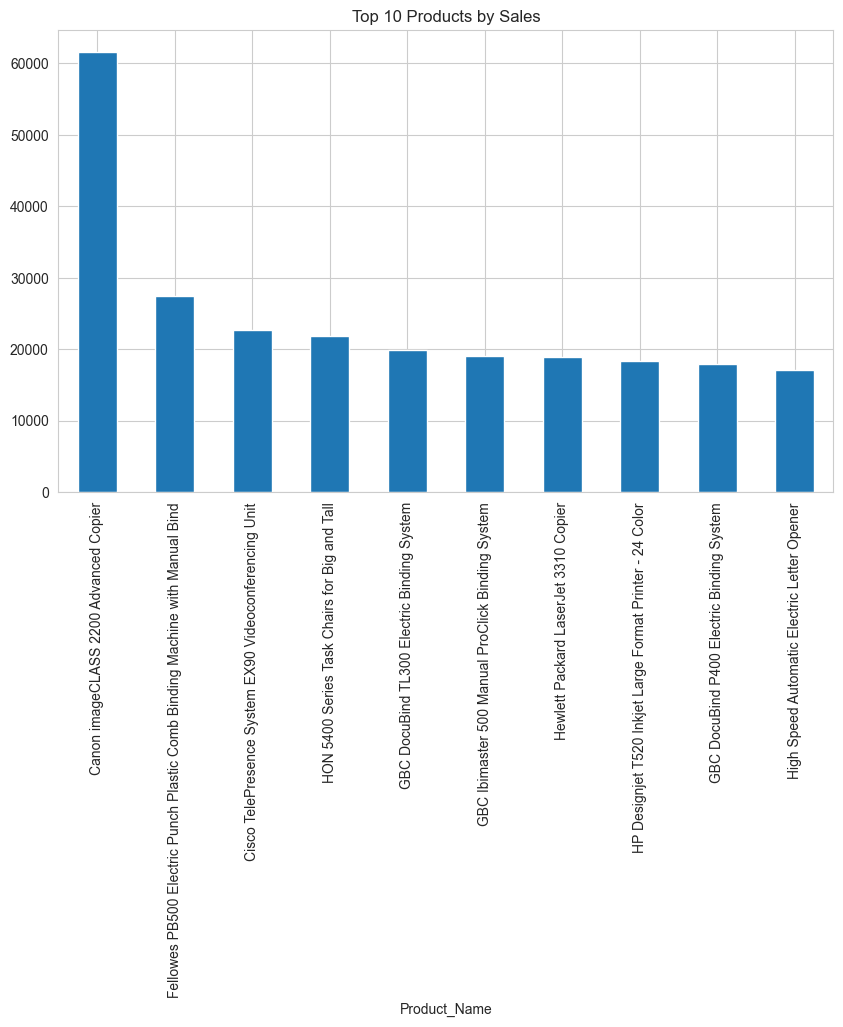

In [16]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,6))

plt.title("Top 10 Products by Sales")
plt.show()

Insight

A small number of products generate a significant share of total revenue.

Business Insight

These products should be promoted more aggressively and prioritized in inventory planning.

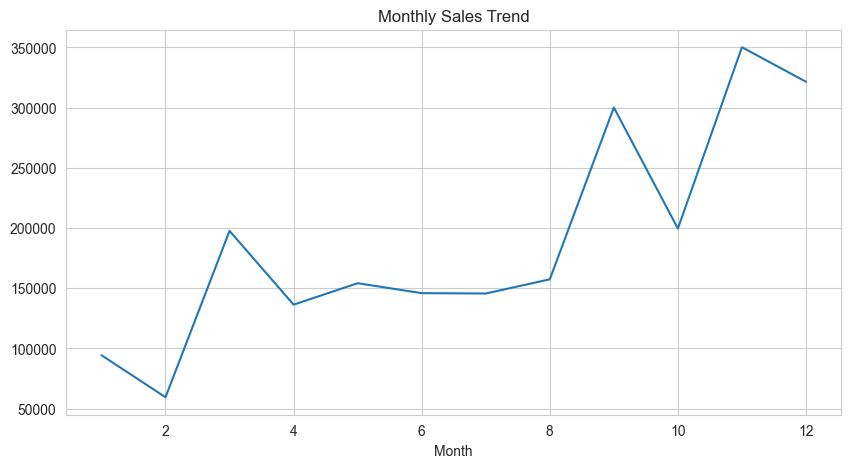

In [17]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.show()

Insight

The chart highlights seasonal patterns in sales.

Business Insight

Seasonal peaks can guide marketing campaigns and promotional strategies.

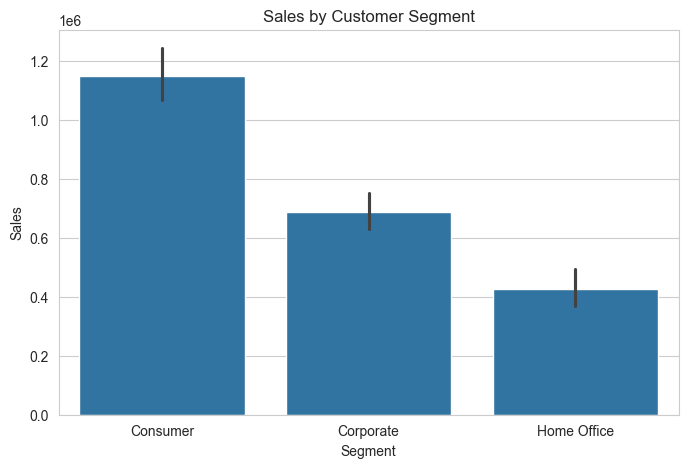

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum)

plt.title("Sales by Customer Segment")
plt.show()

Insight

The chart reveals which customer segment contributes most to revenue.

Business Insight

Marketing campaigns can be tailored to the most profitable customer segment.

## Key Findings

Technology products generate the highest revenue.

The Consumer segment contributes the largest share of sales.

A small number of products drive a large portion of total revenue.

Sales patterns indicate potential seasonal trends.

## Tactical Improvements for Alfido Tech

1. Expand high-performing product categories such as Technology.

2. Improve sales in lower-performing regions through targeted marketing campaigns.

3. Promote top-selling products using discounts and advertising.

4. Introduce product bundles to increase average order value.

5. Use seasonal demand patterns to schedule promotional campaigns.

## Conclusion

This analysis provided valuable insights into Alfido Tech’s sales performance.

The findings highlight strong revenue contributions from specific product categories and customer segments, as well as opportunities for improving regional sales performance.

By implementing data-driven strategies such as targeted promotions, product bundling, and regional marketing campaigns, Alfido Tech can enhance its sales performance and achieve sustainable growth.